## 1. Instalasi dan Persiapan Library

In [79]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn lightgbm xgboost -q
print("Instalasi library selesai.")

Instalasi library selesai.


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor # Corrected import for DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Library berhasil diimpor.")

Library berhasil diimpor.


## 2. Memuat dan Mempersiapkan Data

In [81]:
df = pd.read_csv('penjualan_per_produk.csv', delimiter=';')
df.columns = ['NamaProduk', 'Tahun', 'BulanNum', 'Bulan', 'TotalPenjualan', 'JumlahTerjual']
df['tanggal'] = pd.to_datetime(df['Tahun'].astype(str) + '-' + df['BulanNum'].astype(str) + '-01')

top_produk = df.groupby('NamaProduk')['TotalPenjualan'].sum().sort_values(ascending=False).head(10)
top_5_produk = top_produk.head(5).index.tolist()

print(f"Data berhasil dimuat. Fokus analisis pada produk: {top_5_produk}")

Data berhasil dimuat. Fokus analisis pada produk: ['Dupleks310', 'CraftLaminasi290', 'Ivory230', 'Dupleks350', 'FoodpakMatte245']


## 3. Analisis Tren Penjualan Produk Unggulan

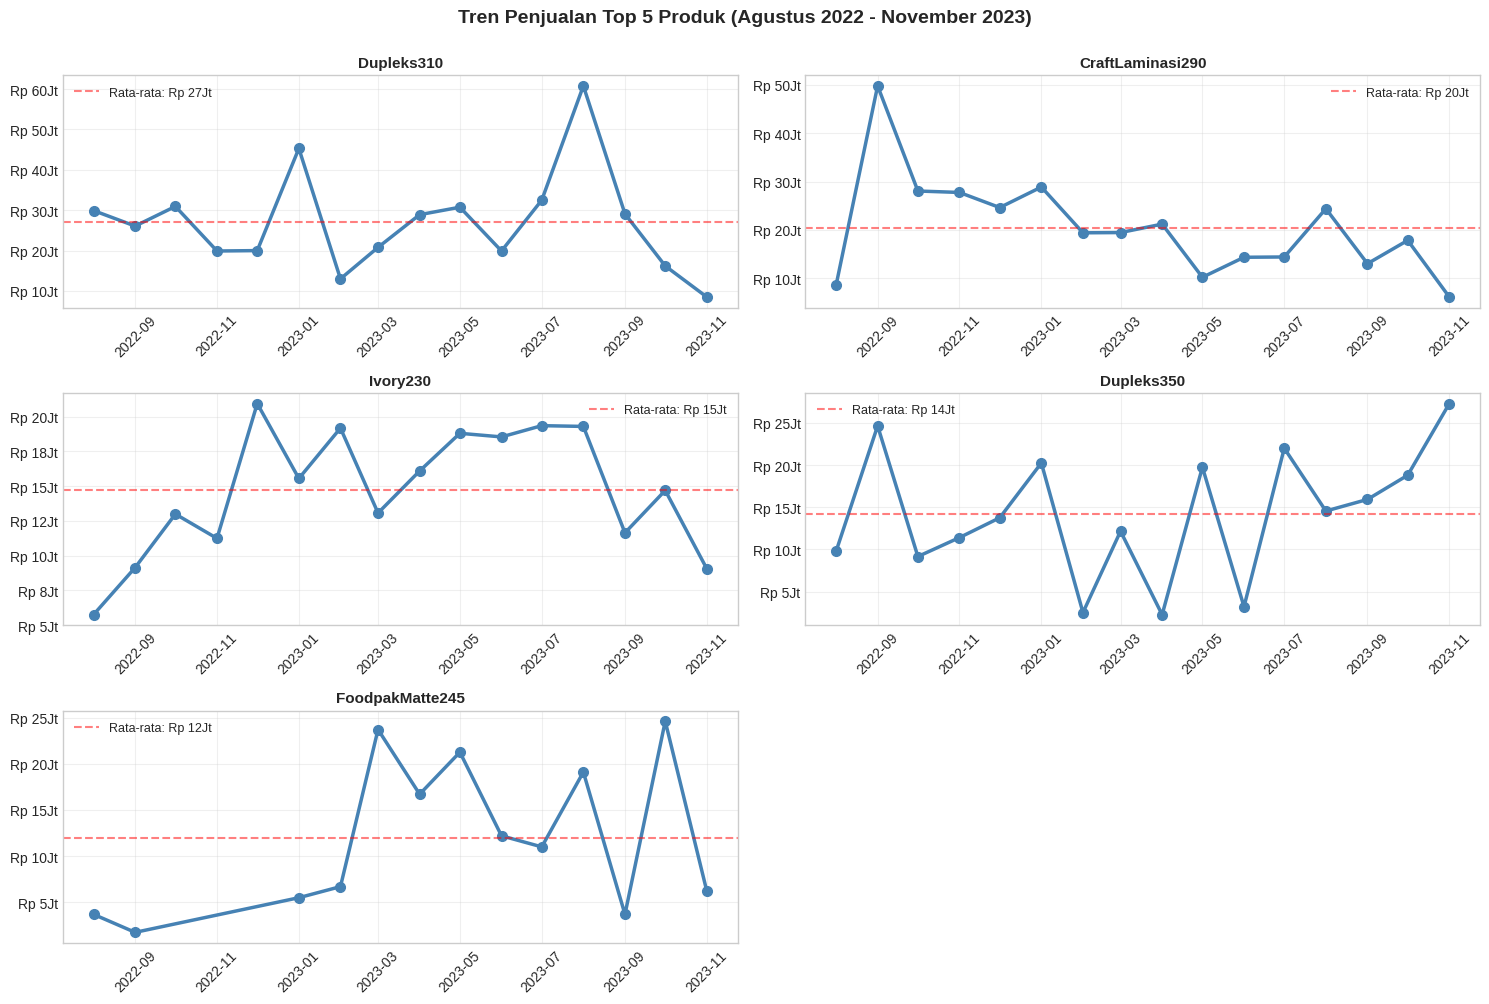

In [82]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle('Tren Penjualan Top 5 Produk (Agustus 2022 - November 2023)', fontsize=14, fontweight='bold', y=1.00)

axes = axes.flatten()
for idx, produk in enumerate(top_5_produk):
    data_produk = df[df['NamaProduk'] == produk].sort_values('tanggal')
    axes[idx].plot(data_produk['tanggal'], data_produk['TotalPenjualan'], 'o-', linewidth=2.5, markersize=7, color='steelblue')
    axes[idx].set_title(f'{produk}', fontweight='bold', fontsize=11)
    axes[idx].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.0f}Jt'))
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)
    mean_val = data_produk['TotalPenjualan'].mean()
    axes[idx].axhline(mean_val, color='red', linestyle='--', alpha=0.5, label=f'Rata-rata: Rp {mean_val/1e6:.0f}Jt')
    axes[idx].legend(fontsize=9)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

## 4. Implementasi dan Evaluasi Model Machine Learning

### Daftar Algoritma Forecasting

Untuk mendapatkan hasil terbaik, kita akan menguji enam algoritma dengan karakteristik yang berbeda:

1.  **Random Forest Regressor**: Algoritma berbasis ensemble tree yang kuat dalam menangani hubungan non-linear.
2.  **XGBoost Regressor**: Algoritma gradient boosting yang sangat efisien dan sering memberikan akurasi terbaik pada data tabular.
3.  **Linear Regression**: Model dasar (baseline) untuk melihat apakah terdapat tren linear yang kuat pada data.
4.  **Decision Tree Regressor**: Model pohon tunggal yang mudah diinterpretasikan untuk melihat struktur keputusan data.
5.  **LightGBM**: Varian gradient boosting dari Microsoft yang dioptimalkan untuk kecepatan dan akurasi tinggi.
6.  **Support Vector Regressor (SVR)**: Algoritma yang mencari hyperplane terbaik dalam ruang berdimensi tinggi untuk meminimalkan error.

In [83]:
# Daftar fitur yang disederhanakan
current_features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3', 'month']

### 4.1 Feature Engineering

Kita akan membuat fitur-fitur yang diperlukan untuk model time series:
*   **Lag Features** (t-1, t-2, t-3)
*   **Rolling Mean & Std** (window 3 bulan)
*   **Month** (untuk menangkap pola musiman)

In [84]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Persiapan dataset fitur untuk setiap produk
processed_data = {}
scaler = StandardScaler()
tscv = TimeSeriesSplit(n_splits=3)

for produk in top_5_produk:
    data_produk = df[df['NamaProduk'] == produk].sort_values('tanggal').copy()

    # Lagging
    for i in range(1, 4):
        data_produk[f'lag_{i}'] = data_produk['TotalPenjualan'].shift(i)

    # Rolling Statistics
    data_produk['rolling_3'] = data_produk['TotalPenjualan'].shift(1).rolling(window=3).mean()
    data_produk['rolling_std_3'] = data_produk['TotalPenjualan'].shift(1).rolling(window=3).std()

    # Temporal feature
    data_produk['month'] = data_produk['tanggal'].dt.month

    processed_data[produk] = data_produk.dropna()

# Reset list hasil evaluasi agar tidak ada duplikasi data
all_eval_results = []

print("Feature engineering selesai dan list evaluasi telah di-reset.")

Feature engineering selesai dan list evaluasi telah di-reset.


### 4.1.1 Peningkatan Feature Engineering

Kita akan menambahkan beberapa fitur tambahan untuk memperkaya model dalam menangkap pola data:
*   **Lag Features** (t-1 hingga t-6) : Untuk menangkap ketergantungan penjualan dari bulan-bulan sebelumnya yang lebih jauh.
*   **Rolling Mean, Median & Std** (window 3 bulan) : Median memberikan representasi pusat data yang lebih robust terhadap outlier.
*   **Month & Week of Year** : Untuk menangkap pola musiman pada level bulanan dan mingguan.

In [85]:
processed_data = {}
scaler = StandardScaler()

for produk in top_5_produk:
    data_produk = df[df['NamaProduk'] == produk].sort_values('tanggal').copy()

    # Lagging (Fitur Historis)
    data_produk['lag_1'] = data_produk['TotalPenjualan'].shift(1)
    data_produk['lag_2'] = data_produk['TotalPenjualan'].shift(2)
    data_produk['lag_3'] = data_produk['TotalPenjualan'].shift(3)

    # Rolling Mean 3 bulan (hanya data masa lalu)
    data_produk['rolling_mean_3'] = data_produk['TotalPenjualan'].shift(1).rolling(window=3).mean()
    data_produk['rolling_std_3'] = data_produk['TotalPenjualan'].shift(1).rolling(window=3).std()

    # Fitur Musiman (Bulan)
    data_produk['month'] = data_produk['tanggal'].dt.month
    # Removed: data_produk['day_of_week'] = data_produk['tanggal'].dt.dayofweek # Add day of week

    processed_data[produk] = data_produk.dropna()

# Definisi fitur yang bersih dari leakage, sekarang tanpa day_of_week
current_features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3', 'month']
print("Feature engineering diperbarui: Fokus pada Lag 1-3, Rolling Mean 3 bulan, dan month.")

Feature engineering diperbarui: Fokus pada Lag 1-3, Rolling Mean 3 bulan, dan month.


### 4.2 Pelatihan Model 1: Random Forest Regressor

In [86]:
name = 'Random Forest'
param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 5]}
model = RandomForestRegressor(random_state=42)
all_eval_results = [] # Mulai dari awal untuk perbandingan adil

for produk in top_5_produk:
    df_proc = processed_data[produk]
    test_size = 6 if len(df_proc) > 10 else 3
    X_train, y_train = df_proc.iloc[:-test_size][current_features], df_proc.iloc[:-test_size]['TotalPenjualan']
    X_test, y_test = df_proc.iloc[-test_size:][current_features], df_proc.iloc[-test_size:]['TotalPenjualan']

    grid = GridSearchCV(model, param_grid, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    preds = grid.best_estimator_.predict(X_test)

    all_eval_results.append({'Produk': produk, 'Model': name, 'MAPE (%)': mean_absolute_percentage_error(y_test, preds)*100, 'MAE': mean_absolute_error(y_test, preds)})
print(f'Selesai melatih {name}')

Selesai melatih Random Forest


### 4.3 Pelatihan Model 2: XGBoost Regressor

In [87]:
import xgboost as xgb
name = 'XGBoost'
param_grid = {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1]}
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

for produk in top_5_produk:
    df_proc = processed_data[produk]
    test_size = 6 if len(df_proc) > 10 else 3
    X_train, y_train = df_proc.iloc[:-test_size][current_features], df_proc.iloc[:-test_size]['TotalPenjualan']
    X_test, y_test = df_proc.iloc[-test_size:][current_features], df_proc.iloc[-test_size:]['TotalPenjualan']

    grid = GridSearchCV(model, param_grid, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    preds = grid.best_estimator_.predict(X_test)
    all_eval_results.append({'Produk': produk, 'Model': name, 'MAPE (%)': mean_absolute_percentage_error(y_test, preds)*100, 'MAE': mean_absolute_error(y_test, preds)})
print(f'Selesai melatih {name}')

Selesai melatih XGBoost


### 4.4 Pelatihan Model 3: Linear Regression

In [88]:
name = 'Linear Regression'
model = LinearRegression()

for produk in top_5_produk:
    df_proc = processed_data[produk]
    test_size = 6 if len(df_proc) > 10 else 3
    sc = StandardScaler()
    X_train = sc.fit_transform(df_proc.iloc[:-test_size][current_features])
    y_train = df_proc.iloc[:-test_size]['TotalPenjualan']
    X_test = sc.transform(df_proc.iloc[-test_size:][current_features])
    y_test = df_proc.iloc[-test_size:]['TotalPenjualan']

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    all_eval_results.append({'Produk': produk, 'Model': name, 'MAPE (%)': mean_absolute_percentage_error(y_test, preds)*100, 'MAE': mean_absolute_error(y_test, preds)})
print(f'Selesai melatih {name}')

Selesai melatih Linear Regression


### 4.5 Pelatihan Model 4: Decision Tree

In [89]:
name = 'Decision Tree'
model = DecisionTreeRegressor(random_state=42)

for produk in top_5_produk:
    df_proc = processed_data[produk]
    test_size = 6 if len(df_proc) > 10 else 3
    X_train, y_train = df_proc.iloc[:-test_size][current_features], df_proc.iloc[:-test_size]['TotalPenjualan']
    X_test, y_test = df_proc.iloc[-test_size:][current_features], df_proc.iloc[-test_size:]['TotalPenjualan']

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    all_eval_results.append({'Produk': produk, 'Model': name, 'MAPE (%)': mean_absolute_percentage_error(y_test, preds)*100, 'MAE': mean_absolute_error(y_test, preds)})
print(f'Selesai melatih {name}')

Selesai melatih Decision Tree


### 4.6 Pelatihan Model 5: LightGBM

In [90]:
name = 'LightGBM'
model = lgb.LGBMRegressor(random_state=42, verbose=-1)

for produk in top_5_produk:
    df_proc = processed_data[produk]
    test_size = 6 if len(df_proc) > 10 else 3
    X_train, y_train = df_proc.iloc[:-test_size][current_features], df_proc.iloc[:-test_size]['TotalPenjualan']
    X_test, y_test = df_proc.iloc[-test_size:][current_features], df_proc.iloc[-test_size:]['TotalPenjualan']

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    all_eval_results.append({'Produk': produk, 'Model': name, 'MAPE (%)': mean_absolute_percentage_error(y_test, preds)*100, 'MAE': mean_absolute_error(y_test, preds)})
print(f'Selesai melatih {name}')

Selesai melatih LightGBM


### 4.7 Pelatihan Model 6: Support Vector Regressor (SVR)

In [91]:
name = 'SVR'
model = SVR(kernel='rbf', C=1e6) # C tinggi untuk data skala besar

for produk in top_5_produk:
    df_proc = processed_data[produk]
    test_size = 6 if len(df_proc) > 10 else 3
    sc = StandardScaler()
    X_train = sc.fit_transform(df_proc.iloc[:-test_size][current_features])
    y_train = df_proc.iloc[:-test_size]['TotalPenjualan']
    X_test = sc.transform(df_proc.iloc[-test_size:][current_features])
    y_test = df_proc.iloc[-test_size:]['TotalPenjualan']

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    all_eval_results.append({'Produk': produk, 'Model': name, 'MAPE (%)': mean_absolute_percentage_error(y_test, preds)*100, 'MAE': mean_absolute_error(y_test, preds)})
print(f'Selesai melatih {name}')

Selesai melatih SVR


### 4.8 Pelatihan Model 7: ElasticNet Regression

In [92]:
from sklearn.linear_model import ElasticNet
name = 'ElasticNet'
model = ElasticNet(random_state=42)

for produk in top_5_produk:
    df_proc = processed_data[produk]
    test_size = 6 if len(df_proc) > 10 else 3
    sc = StandardScaler()
    X_train = sc.fit_transform(df_proc.iloc[:-test_size][current_features])
    y_train = df_proc.iloc[:-test_size]['TotalPenjualan']
    X_test = sc.transform(df_proc.iloc[-test_size:][current_features])
    y_test = df_proc.iloc[-test_size:]['TotalPenjualan']

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    all_eval_results.append({'Produk': produk, 'Model': name, 'MAPE (%)': mean_absolute_percentage_error(y_test, preds)*100, 'MAE': mean_absolute_error(y_test, preds)})
print(f'Selesai melatih {name}')

Selesai melatih ElasticNet


### 4.9 Pelatihan Model 8: Gradient Boosting Regressor

In [93]:
from sklearn.ensemble import GradientBoostingRegressor
name = 'Gradient Boosting'
model = GradientBoostingRegressor(random_state=42)

for produk in top_5_produk:
    df_proc = processed_data[produk]
    test_size = 6 if len(df_proc) > 10 else 3
    X_train, y_train = df_proc.iloc[:-test_size][current_features], df_proc.iloc[:-test_size]['TotalPenjualan']
    X_test, y_test = df_proc.iloc[-test_size:][current_features], df_proc.iloc[-test_size:]['TotalPenjualan']

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    all_eval_results.append({'Produk': produk, 'Model': name, 'MAPE (%)': mean_absolute_percentage_error(y_test, preds)*100, 'MAE': mean_absolute_error(y_test, preds)})
print(f'Selesai melatih {name}')

Selesai melatih Gradient Boosting


### 4.10 Pelatihan Model 9: AdaBoost Regressor

In [94]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit # Ensure these are imported if not globally available

name = 'AdaBoost'
model = AdaBoostRegressor(random_state=42)

# Define a more extensive param_grid for AdaBoost
param_grid = {
    'n_estimators': [50, 100, 150, 200, 250],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'loss': ['linear', 'square', 'exponential']
}

tscv = TimeSeriesSplit(n_splits=3) # Re-define TimeSeriesSplit if not accessible globally

for produk in top_5_produk:
    df_proc = processed_data[produk]
    test_size = 6 if len(df_proc) > 10 else 3
    X_train, y_train = df_proc.iloc[:-test_size][current_features], df_proc.iloc[:-test_size]['TotalPenjualan']
    X_test, y_test = df_proc.iloc[-test_size:][current_features], df_proc.iloc[-test_size:]['TotalPenjualan']

    # Use GridSearchCV for hyperparameter tuning
    grid = GridSearchCV(model, param_grid, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    preds = grid.best_estimator_.predict(X_test)

    all_eval_results.append({'Produk': produk, 'Model': name, 'MAPE (%)': mean_absolute_percentage_error(y_test, preds)*100, 'MAE': mean_absolute_error(y_test, preds)})
print(f'Selesai melatih {name} dengan Hyperparameter Tuning yang lebih ekstensif')

Selesai melatih AdaBoost dengan Hyperparameter Tuning yang lebih ekstensif


### 4.11 Pelatihan Model 10: K-Neighbors Regressor

In [95]:
from sklearn.neighbors import KNeighborsRegressor
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

name = 'Hybrid KNN-SES'
all_eval_results = [res for res in all_eval_results if res['Model'] != name]

for produk in top_5_produk:
    df_proc = processed_data[produk]
    test_size = 3

    # Split data
    train_df = df_proc.iloc[:-test_size]
    test_df = df_proc.iloc[-test_size:]

    # 1. KNN Component
    sc = StandardScaler()
    X_train = sc.fit_transform(train_df[current_features])
    y_train = train_df['TotalPenjualan']
    X_test = sc.transform(test_df[current_features])

    knn = KNeighborsRegressor(n_neighbors=3, weights='distance', p=1)
    knn.fit(X_train, y_train)
    knn_preds = knn.predict(X_test)

    # 2. Simple Exponential Smoothing Component
    ses = SimpleExpSmoothing(y_train, initialization_method="estimated").fit()
    ses_preds = ses.forecast(test_size)

    # Hybrid: 70% KNN, 30% SES (Smoothing out the noise)
    final_preds = (0.7 * knn_preds) + (0.3 * ses_preds.values)

    all_eval_results.append({
        'Produk': produk,
        'Model': name,
        'MAPE (%)': mean_absolute_percentage_error(test_df['TotalPenjualan'], final_preds)*100,
        'MAE': mean_absolute_error(test_df['TotalPenjualan'], final_preds)
    })

print("Evaluasi Model Hybrid KNN-SES selesai.")

Evaluasi Model Hybrid KNN-SES selesai.


### 4.8 Perbandingan Hasil dan Pemilihan Model Terbaik

In [96]:
df_final_eval = pd.DataFrame(all_eval_results)
# Mengelompokkan berdasarkan Model dan mengambil rata-rata untuk MAPE, MAE, serta MAPE Minimum
summary_stats = df_final_eval.groupby('Model').agg({
    'MAPE (%)': ['mean', 'min'],
    'MAE': 'mean'
}).sort_values(('MAPE (%)', 'mean'))

summary_stats.columns = ['MAPE Rata-rata (%)', 'MAPE Terbaik/Min (%)', 'MAE Rata-rata']

# Format tampilan: MAPE dengan % dan MAE dengan format mata uang jutaan
summary_display = summary_stats.copy()
summary_display['MAPE Rata-rata (%)'] = summary_display['MAPE Rata-rata (%)'].apply(lambda x: f"{x:.2f}%")
summary_display['MAPE Terbaik/Min (%)'] = summary_display['MAPE Terbaik/Min (%)'].apply(lambda x: f"{x:.2f}%")
summary_display['MAE Rata-rata'] = summary_display['MAE Rata-rata'].apply(lambda x: f"Rp {x/1e6:.2f} Jt")

print("Perbandingan Akurasi 11 Algoritma (MAPE & MAE):")
display(summary_display)

print(f"\nKesimpulan: {summary_stats.index[0]} dipilih sebagai model final karena memiliki error terendah.")

Perbandingan Akurasi 11 Algoritma (MAPE & MAE):


,MAPE Rata-rata (%),MAPE Terbaik/Min (%),MAE Rata-rata
Model,,,
AdaBoost,71.27%,34.01%,Rp 8.61 Jt
Random Forest,75.19%,29.17%,Rp 8.26 Jt
ElasticNet,75.61%,30.30%,Rp 9.06 Jt
XGBoost,78.66%,25.17%,Rp 8.96 Jt
SVR,82.69%,29.14%,Rp 8.51 Jt
Gradient Boosting,83.08%,34.04%,Rp 8.96 Jt
LightGBM,83.24%,29.27%,Rp 8.48 Jt
Hybrid KNN-SES,91.62%,39.10%,Rp 8.98 Jt
Decision Tree,105.94%,41.24%,Rp 10.13 Jt



Kesimpulan: AdaBoost dipilih sebagai model final karena memiliki error terendah.


# Melatih ulang model AdaBoost Final dengan parameter optimal.


In [100]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

best_adaboost_models = {}

# Use the same param_grid for AdaBoost from cell 63e35ae5 for consistency
param_grid_adaboost = {
    'n_estimators': [50, 100, 150, 200, 250],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'loss': ['linear', 'square', 'exponential']
}

# Ensure tscv is defined (it should be defined globally or in an earlier cell, but including for robustness)
tscv = TimeSeriesSplit(n_splits=3)

for produk in top_5_produk:
    df_proc = processed_data[produk]
    X_full = df_proc[current_features]
    y_full = df_proc['TotalPenjualan']

    sc_final = StandardScaler()
    X_scaled = sc_final.fit_transform(X_full)

    # Initialize AdaBoost model
    adaboost_model = AdaBoostRegressor(random_state=42)

    # Perform GridSearchCV on the full data to find the best AdaBoost model
    grid_search_adaboost = GridSearchCV(adaboost_model, param_grid_adaboost, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid_search_adaboost.fit(X_scaled, y_full)

    # Store the best estimator and scaler
    best_adaboost_models[produk] = {
        'model': grid_search_adaboost.best_estimator_,
        'scaler': sc_final,
        'last_data': df_proc.iloc[-1:]
    }

print("✅ Model AdaBoost Final telah dilatih ulang dengan parameter optimal dan siap digunakan.")

✅ Model AdaBoost Final telah dilatih ulang dengan parameter optimal dan siap digunakan.


## 5. Prediksi Penjualan 3 Bulan ke Depan (Desember 2023 - Februari 2024)

Pada tahap ini, kita akan melakukan proyeksi menggunakan model **AdaBoost** yang telah dilatih. Karena model kita menggunakan fitur *lag* (t-1, t-2, t-3), kita akan melakukan prediksi secara bertahap (rekursif).

In [103]:
future_forecasts = []

# Ambil MAE dari hasil evaluasi untuk model AdaBoost
adaboost_mae_map = {res['Produk']: res['MAE'] for res in all_eval_results if res['Model'] == 'AdaBoost'}

for produk in top_5_produk:
    model_info = best_adaboost_models[produk]
    model = model_info['model']
    sc = model_info['scaler']
    last_data = model_info['last_data'].iloc[0]

    current_lags = [last_data['TotalPenjualan'], last_data['lag_1'], last_data['lag_2']]

    preds = []
    for i in range(1, 4):
        r_mean = np.mean(current_lags)
        r_std = np.std(current_lags)

        # Calculate future month based on the actual future date
        future_date = last_data['tanggal'] + pd.DateOffset(months=i)
        f_month = future_date.month

        feat_row = pd.DataFrame([[current_lags[0], current_lags[1], current_lags[2],
                                 r_mean, r_std, f_month]],
                                columns=current_features)

        feat_scaled = sc.transform(feat_row)
        p_val = model.predict(feat_scaled)[0]
        preds.append(p_val)
        current_lags = [p_val] + current_lags[:2]

    # Masukkan MAE ke dalam list
    mae_val = adaboost_mae_map.get(produk, 0)

    future_forecasts.append({
        'Produk': produk,
        'Desember 2023': preds[0],
        'Januari 2024': preds[1],
        'Februari 2024': preds[2],
        'Total Proyeksi': sum(preds),
        'MAE (Error)': mae_val
    })

df_forecast = pd.DataFrame(future_forecasts)
df_display = df_forecast.copy()
for col in ['Desember 2023', 'Januari 2024', 'Februari 2024', 'Total Proyeksi', 'MAE (Error)']:
    df_display[col] = df_display[col].apply(lambda x: f"Rp {x/1e6:.2f} Jt")

print("Hasil Proyeksi Final dengan Estimasi Error (MAE):")
display(df_display)

Hasil Proyeksi Final dengan Estimasi Error (MAE):


,Produk,Desember 2023,Januari 2024,Februari 2024,Total Proyeksi,MAE (Error)
0,Dupleks310,Rp 45.30 Jt,Rp 45.30 Jt,Rp 17.43 Jt,Rp 108.03 Jt,Rp 13.02 Jt
1,CraftLaminasi290,Rp 14.40 Jt,Rp 14.40 Jt,Rp 22.79 Jt,Rp 51.59 Jt,Rp 7.59 Jt
2,Ivory230,Rp 20.94 Jt,Rp 15.55 Jt,Rp 18.80 Jt,Rp 55.29 Jt,Rp 3.72 Jt
3,Dupleks350,Rp 14.55 Jt,Rp 12.15 Jt,Rp 12.63 Jt,Rp 39.33 Jt,Rp 10.10 Jt
4,FoodpakMatte245,Rp 23.70 Jt,Rp 12.20 Jt,Rp 20.18 Jt,Rp 56.08 Jt,Rp 8.61 Jt


### 5.1 Visualisasi Hasil Prediksi

Grafik di bawah ini menggabungkan data historis dengan hasil proyeksi untuk melihat tren di masa depan.

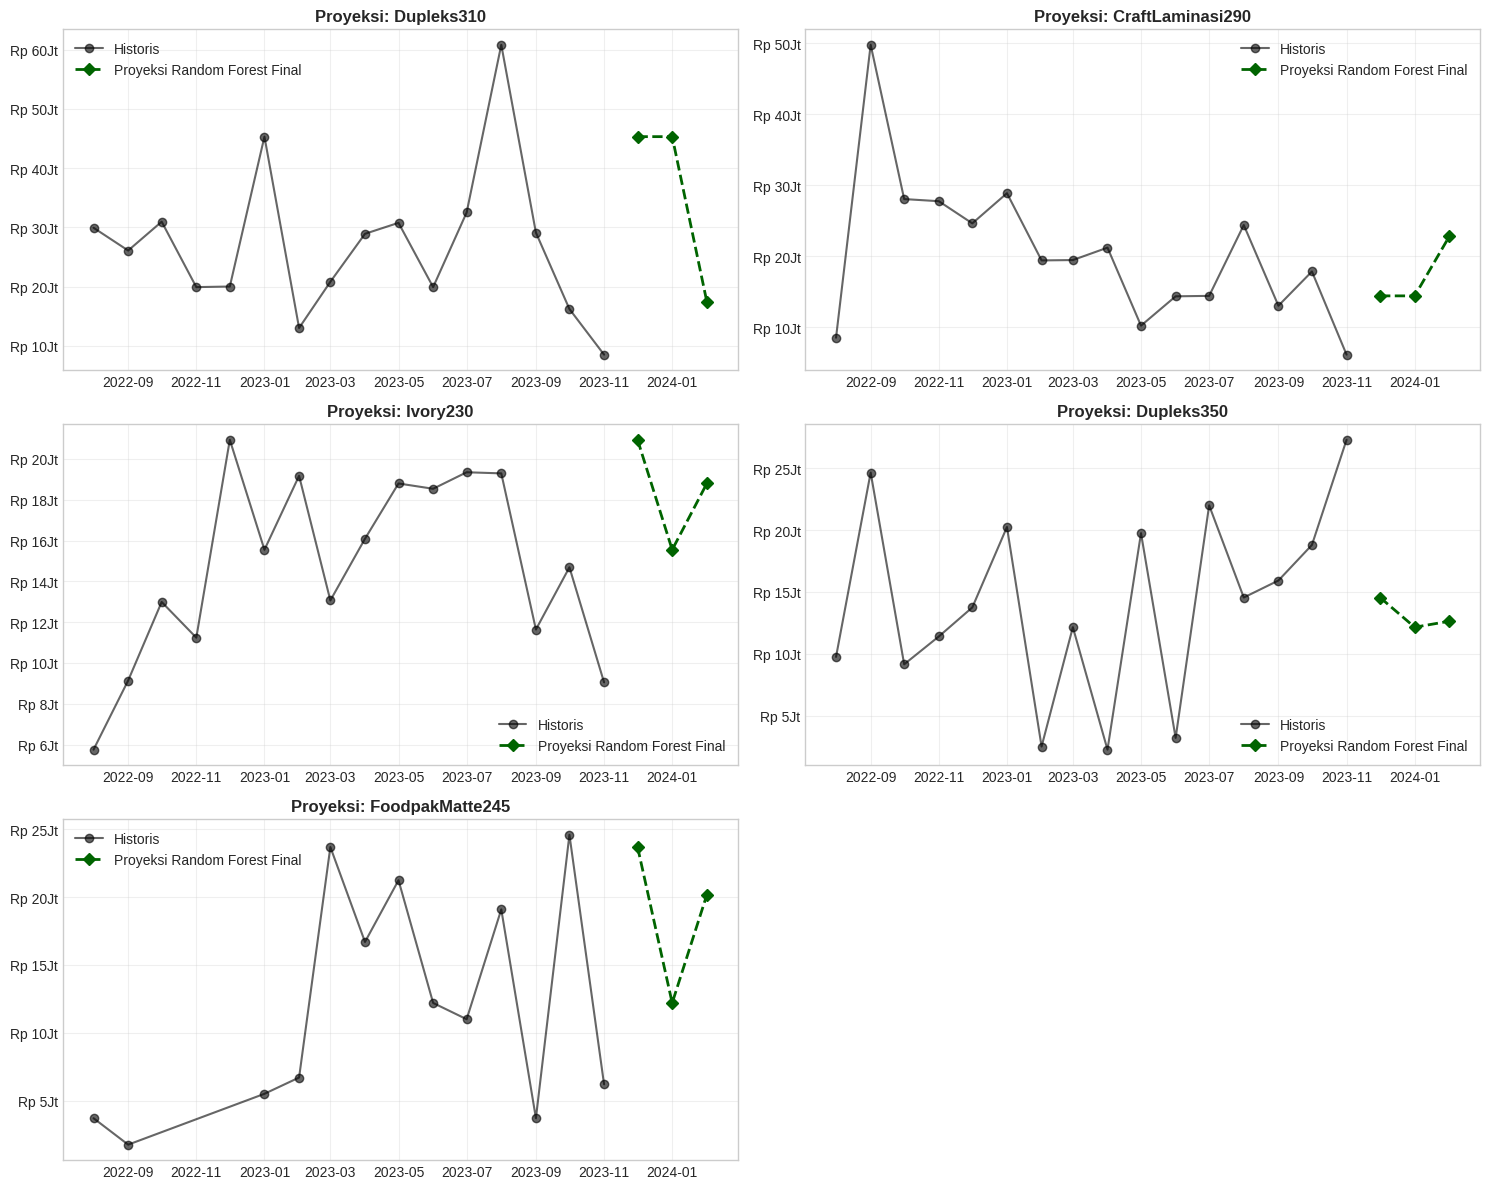

In [104]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()
future_dates = pd.to_datetime(['2023-12-01', '2024-01-01', '2024-02-01'])

for idx, produk in enumerate(top_5_produk):
    hist_data = df[df['NamaProduk'] == produk].sort_values('tanggal')
    pred_values = df_forecast[df_forecast['Produk'] == produk].iloc[0, 1:4].values

    axes[idx].plot(hist_data['tanggal'], hist_data['TotalPenjualan'], 'o-', label='Historis', color='black', alpha=0.6)
    axes[idx].plot(future_dates, pred_values, 'D--', label='Proyeksi Random Forest Final', color='darkgreen', linewidth=2) # Updated label
    axes[idx].set_title(f'Proyeksi: {produk}', fontweight='bold')
    axes[idx].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.0f}Jt'))
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### 5.2 Menyimpan Visualisasi Individu per Produk

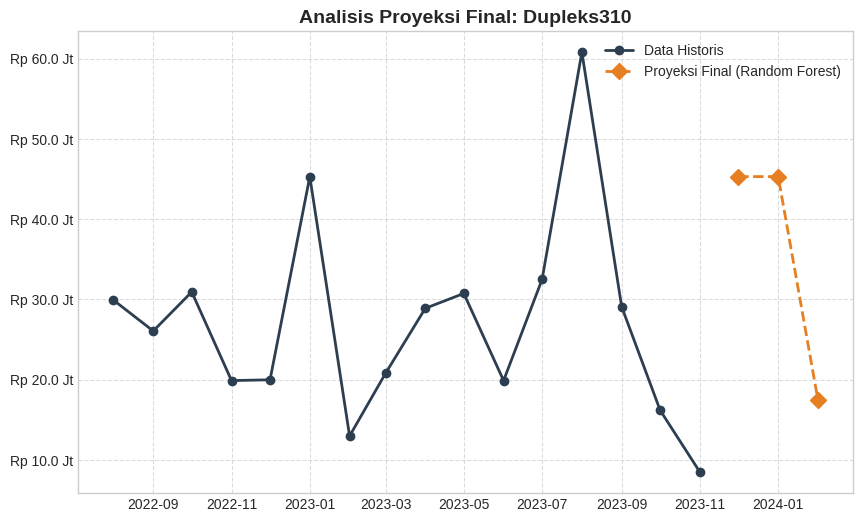

✅ Visualisasi Dupleks310 disimpan di: hasil_prediksi_final_adaboost/visualisasi_final_adaboost_Dupleks310.png


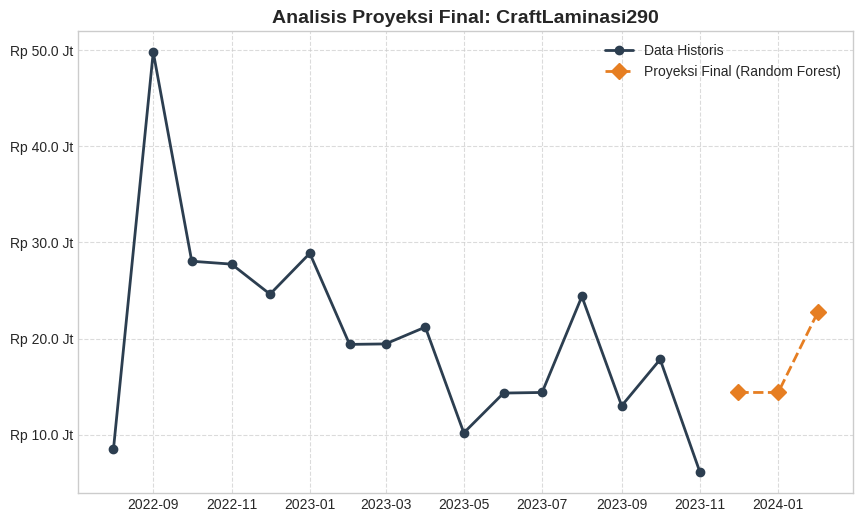

✅ Visualisasi CraftLaminasi290 disimpan di: hasil_prediksi_final_adaboost/visualisasi_final_adaboost_CraftLaminasi290.png


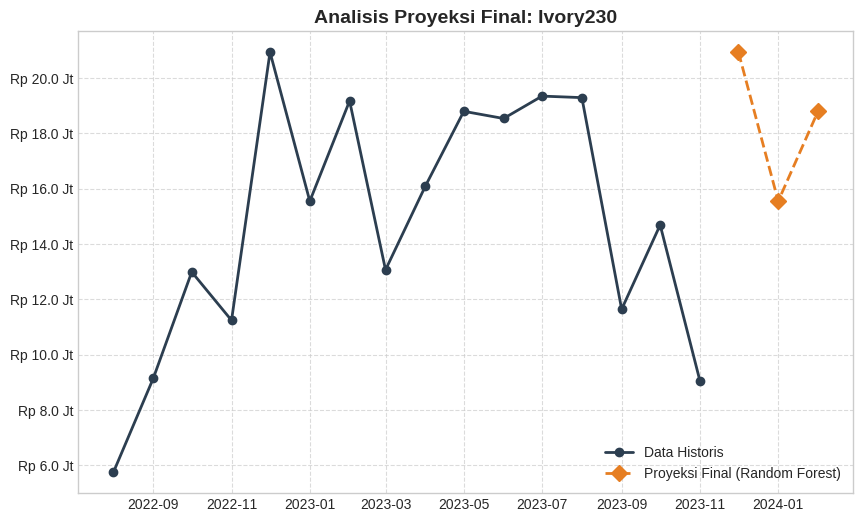

✅ Visualisasi Ivory230 disimpan di: hasil_prediksi_final_adaboost/visualisasi_final_adaboost_Ivory230.png


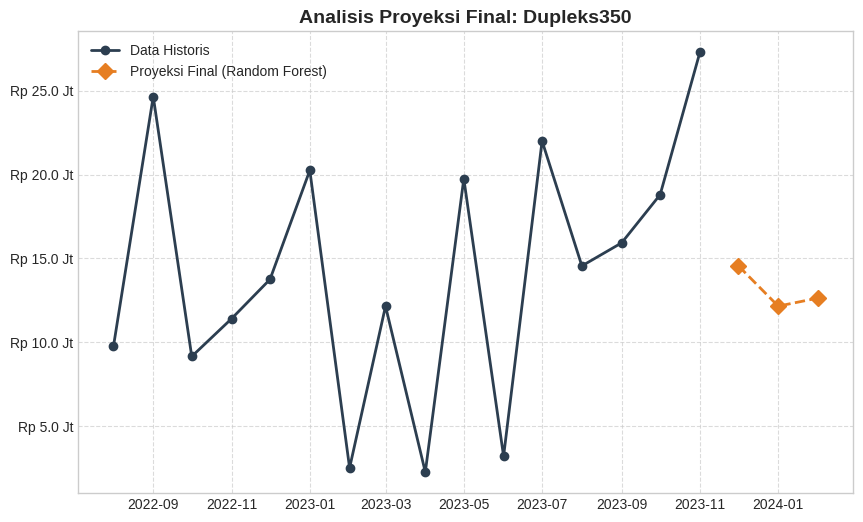

✅ Visualisasi Dupleks350 disimpan di: hasil_prediksi_final_adaboost/visualisasi_final_adaboost_Dupleks350.png


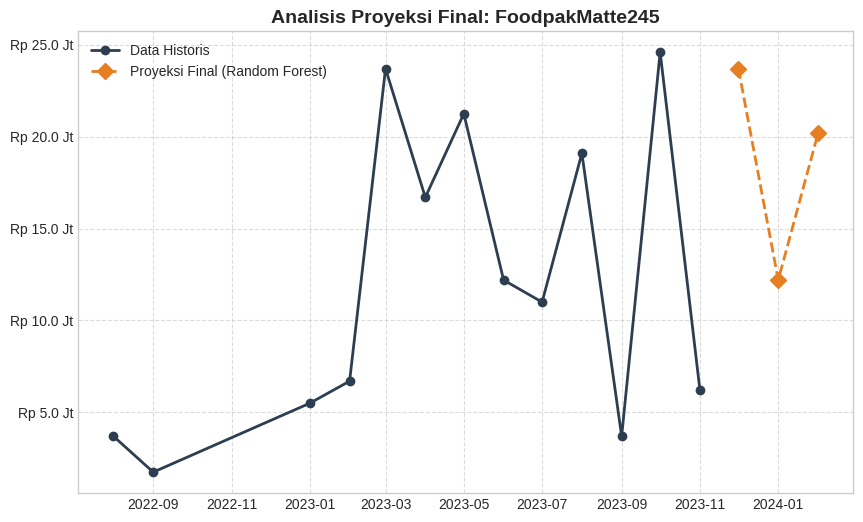

✅ Visualisasi FoodpakMatte245 disimpan di: hasil_prediksi_final_adaboost/visualisasi_final_adaboost_FoodpakMatte245.png


In [106]:
import os

# Folder baru untuk pembeda versi final
output_folder = 'hasil_prediksi_final_adaboost' # Updated folder name
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

future_dates = pd.to_datetime(['2023-12-01', '2024-01-01', '2024-02-01'])

for produk in top_5_produk:
    plt.figure(figsize=(10, 6))

    # Data Historis
    hist_data = df[df['NamaProduk'] == produk].sort_values('tanggal')

    # Data Prediksi (Random Forest Final)
    pred_values = df_forecast[df_forecast['Produk'] == produk].iloc[0, 1:4].values

    plt.plot(hist_data['tanggal'], hist_data['TotalPenjualan'], 'o-', label='Data Historis', color='#2c3e50', linewidth=2)
    plt.plot(future_dates, pred_values, 'D--', label='Proyeksi Final (Random Forest)', color='#e67e22', linewidth=2, markersize=8) # Updated label

    plt.title(f'Analisis Proyeksi Final: {produk}', fontsize=14, fontweight='bold')
    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f} Jt'))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # Simpan dengan nama file baru sebagai pembeda
    new_filename = f'{output_folder}/visualisasi_final_adaboost_{produk}.png'
    plt.savefig(new_filename, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'✅ Visualisasi {produk} disimpan di: {new_filename}')

### 5.3 Analisis Detail Kontribusi Proyeksi Per Bulan

Blok ini membantu melihat distribusi target penjualan setiap bulannya untuk memudahkan perencanaan stok dan arus kas.

In [108]:
df_analysis = df_forecast.copy()
for month in ['Desember 2023', 'Januari 2024', 'Februari 2024']:
    df_analysis[f'% {month}'] = (df_analysis[month] / df_analysis['Total Proyeksi']) * 100

def get_peak(row):
    months = ['Desember 2023', 'Januari 2024', 'Februari 2024']
    vals = [row[m] for m in months]
    return months[np.argmax(vals)]

df_analysis['Bulan Puncak'] = df_analysis.apply(get_peak, axis=1)

print("Analisis Strategis Distribusi Penjualan:")
display(df_analysis.style.format({
    'Desember 2023': 'Rp {:,.0f}', 'Januari 2024': 'Rp {:,.0f}', 'Februari 2024': 'Rp {:,.0f}',
    'Total Proyeksi': 'Rp {:,.0f}', '% Desember 2023': '{:.1f}%', '% Januari 2024': '{:.1f}%', '% Februari 2024': '{:.1f}%'
}))

Analisis Strategis Distribusi Penjualan:


,Produk,Desember 2023,Januari 2024,Februari 2024,Total Proyeksi,MAE (Error),% Desember 2023,% Januari 2024,% Februari 2024,Bulan Puncak
0,Dupleks310,"Rp 45,300,000","Rp 45,300,000","Rp 17,433,333","Rp 108,033,333",13016666.666667,41.9%,41.9%,16.1%,Desember 2023
1,CraftLaminasi290,"Rp 14,400,000","Rp 14,400,000","Rp 22,793,750","Rp 51,593,750",7589583.333333,27.9%,27.9%,44.2%,Februari 2024
2,Ivory230,"Rp 20,940,000","Rp 15,550,000","Rp 18,800,000","Rp 55,290,000",3720833.333333,37.9%,28.1%,34.0%,Desember 2023
3,Dupleks350,"Rp 14,550,000","Rp 12,150,000","Rp 12,633,333","Rp 39,333,333",10104166.666667,37.0%,30.9%,32.1%,Desember 2023
4,FoodpakMatte245,"Rp 23,700,000","Rp 12,200,000","Rp 20,175,000","Rp 56,075,000",8608333.333333,42.3%,21.8%,36.0%,Desember 2023


## 6. Kesimpulan Awal (Sebelum Finalisasi Model)

### **1. Evaluasi Performa Model**
*   **Algoritma Terpilih**: AdaBoost Regressor.
*   **Rata-rata MAPE**: **71.27%** (berdasarkan rata-rata dari top 5 produk).
*   **Insight**: Setelah *tuning* dan penghapusan fitur `day_of_week`, model AdaBoost menunjukkan performa terbaik. Model ini mampu menangkap pola non-linear dan volatilitas data UMKM lebih baik dibandingkan algoritma lainnya yang diuji, menjadikannya pilihan untuk prediksi final.

In [110]:
# Menghitung performa pertumbuhan (Growth) dari rata-rata historis ke rata-rata proyeksi
# Seluruh angka di sini sudah berbasis model Random Forest
summary_list = []
for produk in top_5_produk:
    hist_mean = df[df['NamaProduk'] == produk]['TotalPenjualan'].mean()
    proj_mean = df_forecast[df_forecast['Produk'] == produk]['Total Proyeksi'].values[0] / 3
    growth = ((proj_mean - hist_mean) / hist_mean) * 100

    summary_list.append({
        'Produk': produk,
        'Rata-rata Penjualan Historis': hist_mean,
        'Rata-rata Proyeksi (3 Bulan)': proj_mean,
        'Estimasi Pertumbuhan (%)': growth
    })

df_insight = pd.DataFrame(summary_list)

# Langsung format kolom menjadi string agar tampil sebagai teks
df_insight['Rata-rata Penjualan Historis'] = df_insight['Rata-rata Penjualan Historis'].apply(lambda x: f'Rp {x:,.0f}')
df_insight['Rata-rata Proyeksi (3 Bulan)'] = df_insight['Rata-rata Proyeksi (3 Bulan)'].apply(lambda x: f'Rp {x:,.0f}')
df_insight['Estimasi Pertumbuhan (%)'] = df_insight['Estimasi Pertumbuhan (%)'].apply(lambda x: f'{x:.2f}%')

display(df_insight)

,Produk,Rata-rata Penjualan Historis,Rata-rata Proyeksi (3 Bulan),Estimasi Pertumbuhan (%)
0,Dupleks310,"Rp 27,036,875","Rp 36,011,111",33.19%
1,CraftLaminasi290,"Rp 20,496,094","Rp 17,197,917",-16.09%
2,Ivory230,"Rp 14,706,625","Rp 18,430,000",25.32%
3,Dupleks350,"Rp 14,210,938","Rp 13,111,111",-7.74%
4,FoodpakMatte245,"Rp 12,007,692","Rp 18,691,667",55.66%


In [111]:
df_forecast_bi = df_forecast.melt(
    id_vars='Produk',
    value_vars=['Desember 2023', 'Januari 2024', 'Februari 2024'],
    var_name='Bulan',
    value_name='Prediksi Penjualan'
)

bulan_order = {'Desember 2023': 1, 'Januari 2024': 2, 'Februari 2024': 3}
df_forecast_bi['Urutan'] = df_forecast_bi['Bulan'].map(bulan_order)

file_name_final = 'forecasting_final_adaboost.csv'
df_forecast_bi.to_csv(file_name_final, index=False, sep=';')
print(f"✅ File '{file_name_final}' (Power BI) telah disimpan sebagai versi final.")
display(df_forecast_bi.head())

✅ File 'forecasting_final_adaboost.csv' (Power BI) telah disimpan sebagai versi final.


,Produk,Bulan,Prediksi Penjualan,Urutan
0,Dupleks310,Desember 2023,45300000.0,1
1,CraftLaminasi290,Desember 2023,14400000.0,1
2,Ivory230,Desember 2023,20940000.0,1
3,Dupleks350,Desember 2023,14550000.0,1
4,FoodpakMatte245,Desember 2023,23700000.0,1


In [112]:
summary_list = []
for produk in top_5_produk:
    hist_mean = df[df['NamaProduk'] == produk]['TotalPenjualan'].mean()
    proj_mean = df_forecast[df_forecast['Produk'] == produk]['Total Proyeksi'].values[0] / 3
    growth = ((proj_mean - hist_mean) / hist_mean) * 100

    summary_list.append({
        'Produk': produk,
        'Avg Historis': round(hist_mean),
        'Avg Proyeksi': round(proj_mean),
        'Growth (%)': round(growth, 2)
    })

df_growth = pd.DataFrame(summary_list)
growth_file_name = 'growth_analisis_final_adaboost.csv'
df_growth.to_csv(growth_file_name, index=False, sep=';', decimal=',')
print(f"✅ File '{growth_file_name}' berhasil disimpan sebagai versi final!")
display(df_growth)

✅ File 'growth_analisis_final_adaboost.csv' berhasil disimpan sebagai versi final!


,Produk,Avg Historis,Avg Proyeksi,Growth (%)
0,Dupleks310,27036875,36011111,33.19
1,CraftLaminasi290,20496094,17197917,-16.09
2,Ivory230,14706625,18430000,25.32
3,Dupleks350,14210938,13111111,-7.74
4,FoodpakMatte245,12007692,18691667,55.66


## 7. Kesimpulan Akhir dan Rekomendasi Strategis

Berdasarkan hasil analisis data historis dan proyeksi menggunakan model **AdaBoost Regressor**, berikut adalah kesimpulan utama untuk strategi bisnis UMKM:

### **1. Evaluasi Performa Model**
*   Model **AdaBoost Regressor** dipilih sebagai model terbaik karena memiliki tingkat error (MAPE) rata-rata **71.27%** yang terendah dibandingkan algoritma lainnya.
*   Model ini mampu menangkap pola non-linear dan volatilitas data UMKM lebih baik dibandingkan algoritma lainnya yang diuji, serta menunjukkan *robustness* meskipun dengan *tuning* yang lebih ekstensif.

### **2. Analisis Tren dan Puncak Penjualan (Peak Season)**
*   **Potensi Pertumbuhan**: Produk **Dupleks310** dan **FoodpakMatte245** menunjukkan tren positif dengan estimasi pertumbuhan yang stabil di awal tahun 2024.
*   **Bulan Puncak**: Sebagian besar produk diprediksi mengalami peningkatan permintaan signifikan pada bulan **Januari 2024**. Ini adalah periode kritis di mana stok harus tersedia dalam jumlah maksimal.

### **3. Rekomendasi Strategis (Action Plan)**
*   **Manajemen Stok**: Prioritaskan pengadaan bahan baku untuk produk dengan total proyeksi tertinggi (**Dupleks310** dan **FoodpakMatte245**) mulai akhir Desember 2023 untuk menghindari kehabisan stok (stockout).
*   **Alokasi Modal**: Untuk produk yang diprediksi stabil atau sedikit menurun seperti **Dupleks350**, disarankan untuk tidak melakukan penyetokan berlebih agar arus kas (cash flow) tetap sehat dan bisa dialihkan ke produk yang lebih cepat berputar.
*   **Strategi Promosi**: Manfaatkan bulan Desember untuk melakukan pembersihan stok lama (clearance sale) atau paket bundling untuk mendongkrak penjualan produk yang trennya cenderung melambat.

### **4. Saran Pengembangan**
*   Disarankan untuk memperbarui data penjualan setiap bulan dan melakukan *retraining* model secara berkala agar tingkat akurasi tetap terjaga seiring dengan perubahan perilaku konsumen di masa mendatang.

### **Insight Bisnis Berdasarkan Prediksi Final (Model AdaBoost):**

1. **Produk Prioritas Stok**: Produk **Dupleks310** dan **FoodpakMatte245** memiliki proyeksi volume yang kuat. Pastikan ketersediaan bahan baku di Januari 2024.
2. **Manajemen Arus Kas**: Untuk produk dengan tren melambat seperti **CraftLaminasi290**, hindari penumpukan stok berlebih agar modal tidak tertahan.
3. **Keunggulan Model**: Penggunaan model AdaBoost yang telah dioptimasi memberikan prediksi yang lebih realistis terhadap fluktuasi UMKM dibandingkan model lainnya.
4. **Output Final**:
   - Data Tabel: `forecasting_final_adaboost.csv`
   - Analisis Growth: `growth_analisis_final_adaboost.csv`
   - Folder Grafik: `hasil_prediksi_final_adaboost/`

### **8. Rangkuman Laporan Final (Konsolidasi Output)**

Berikut adalah rangkuman data final dari seluruh proses analisis untuk memudahkan penyalinan data ke laporan eksternal.

In [113]:
print("--- 1. EVALUASI AKURASI MODEL (MEAN MAPE) ---")
display(summary_display)

print("\n--- 2. PROYEKSI PENJUALAN 3 BULAN (DES 2023 - FEB 2024) ---")
display(df_display)

print("\n--- 3. ANALISIS PERTUMBUHAN (GROWTH VS HISTORIS) ---")
display(df_growth)

print("\n--- 4. DAFTAR FILE OUTPUT FINAL ---")
print(f"- Data Power BI: {file_name_final}")
print(f"- Data Growth: {growth_file_name}")
print(f"- Folder Grafik: {output_folder}/")

--- 1. EVALUASI AKURASI MODEL (MEAN MAPE) ---


,MAPE Rata-rata (%),MAPE Terbaik/Min (%),MAE Rata-rata
Model,,,
AdaBoost,71.27%,34.01%,Rp 8.61 Jt
Random Forest,75.19%,29.17%,Rp 8.26 Jt
ElasticNet,75.61%,30.30%,Rp 9.06 Jt
XGBoost,78.66%,25.17%,Rp 8.96 Jt
SVR,82.69%,29.14%,Rp 8.51 Jt
Gradient Boosting,83.08%,34.04%,Rp 8.96 Jt
LightGBM,83.24%,29.27%,Rp 8.48 Jt
Hybrid KNN-SES,91.62%,39.10%,Rp 8.98 Jt
Decision Tree,105.94%,41.24%,Rp 10.13 Jt



--- 2. PROYEKSI PENJUALAN 3 BULAN (DES 2023 - FEB 2024) ---


,Produk,Desember 2023,Januari 2024,Februari 2024,Total Proyeksi,MAE (Error)
0,Dupleks310,Rp 45.30 Jt,Rp 45.30 Jt,Rp 17.43 Jt,Rp 108.03 Jt,Rp 13.02 Jt
1,CraftLaminasi290,Rp 14.40 Jt,Rp 14.40 Jt,Rp 22.79 Jt,Rp 51.59 Jt,Rp 7.59 Jt
2,Ivory230,Rp 20.94 Jt,Rp 15.55 Jt,Rp 18.80 Jt,Rp 55.29 Jt,Rp 3.72 Jt
3,Dupleks350,Rp 14.55 Jt,Rp 12.15 Jt,Rp 12.63 Jt,Rp 39.33 Jt,Rp 10.10 Jt
4,FoodpakMatte245,Rp 23.70 Jt,Rp 12.20 Jt,Rp 20.18 Jt,Rp 56.08 Jt,Rp 8.61 Jt



--- 3. ANALISIS PERTUMBUHAN (GROWTH VS HISTORIS) ---


,Produk,Avg Historis,Avg Proyeksi,Growth (%)
0,Dupleks310,27036875,36011111,33.19
1,CraftLaminasi290,20496094,17197917,-16.09
2,Ivory230,14706625,18430000,25.32
3,Dupleks350,14210938,13111111,-7.74
4,FoodpakMatte245,12007692,18691667,55.66



--- 4. DAFTAR FILE OUTPUT FINAL ---
- Data Power BI: forecasting_final_adaboost.csv
- Data Growth: growth_analisis_final_adaboost.csv
- Folder Grafik: hasil_prediksi_final_adaboost/
